# RNA para Regresión con Diabetes

Demo simple de red neuronal artificial en Keras para un problema de regresión.


## 1. Importar librerías


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow import keras
from tensorflow.keras import layers


## 2. Cargar dataset
El objetivo es predecir una medida cuantitativa de progresión de diabetes.


In [2]:
data = load_diabetes()
X = data.data
y = data.target

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Primeros 5 valores objetivo:", y[:5])


Forma de X: (442, 10)
Forma de y: (442,)
Primeros 5 valores objetivo: [151.  75. 141. 206. 135.]


## 3. Separar entrenamiento y validación


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)


Entrenamiento: (353, 10) (353,)
Validación: (89, 10) (89,)


## 4. Estandarizar variables


In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


## 5. Crear la red neuronal
Como es regresión, la salida es una sola neurona sin función de activación.


In [5]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compilar modelo


In [6]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


## 7. Entrenar modelo


In [7]:
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 29614.1719 - mae: 153.3242 - val_loss: 26306.5430 - val_mae: 144.8882
Epoch 2/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29372.3965 - mae: 152.5551 - val_loss: 26038.0273 - val_mae: 144.0110
Epoch 3/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29054.8047 - mae: 151.5611 - val_loss: 25675.9531 - val_mae: 142.8355
Epoch 4/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28611.1992 - mae: 150.1435 - val_loss: 25150.6855 - val_mae: 141.1259
Epoch 5/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27946.0801 - mae: 148.1015 - val_loss: 24411.2930 - val_mae: 138.7201
Epoch 6/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27029.3320 - mae: 145.1680 - val_loss: 23357.4316 - val_mae: 135.3012
Epoch 7/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25726.9551 - mae: 141.0476 - val_loss: 21977.4277 - val_mae: 130.6813
Epoch 8/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24044.4453 - mae: 135.4364 - val_loss: 20112.

## 8. Evaluar modelo


In [8]:
loss, mae = model.evaluate(X_val, y_val, verbose=0)
print(f"MAE (Keras): {mae:.4f}")


MAE (Keras): 43.6154


## 9. Predicciones y métricas


In [9]:
y_pred = model.predict(X_val).ravel()

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
MAE:  43.6154
MSE:  2930.9377
RMSE: 54.1381
R²:   0.4468


## 10. Graficar entrenamiento


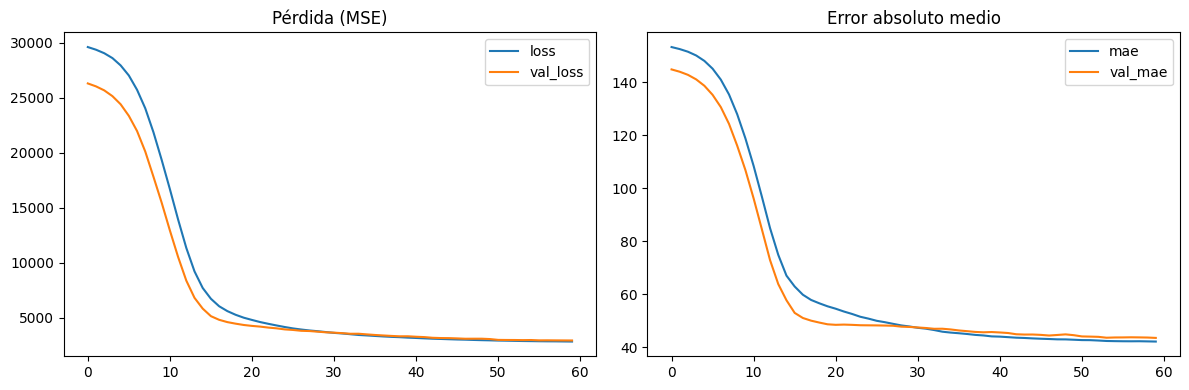

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida (MSE)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.title("Error absoluto medio")
plt.legend()

plt.tight_layout()
plt.show()


## 11. Comparar valores reales vs predichos


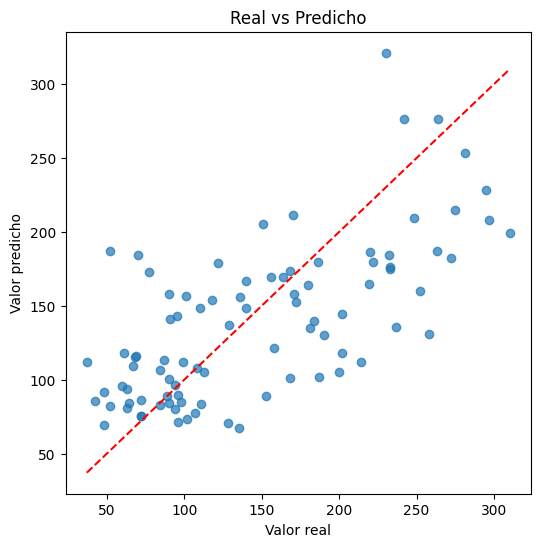

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.7)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Real vs Predicho")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.show()


## 12. Probar algunas predicciones


In [12]:
for i in range(5):
    print(f"Real: {y_val[i]:.2f} | Predicho: {y_pred[i]:.2f}")


Real: 219.00 | Predicho: 164.86
Real: 70.00 | Predicho: 184.67
Real: 202.00 | Predicho: 144.13
Real: 230.00 | Predicho: 321.23
Real: 111.00 | Predicho: 83.28
